In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Chargement des données

In [2]:
data = pd.read_csv('HRDataset_v14.csv')
data = data.drop(columns=['Employee_Name', 'ManagerName'])
data.head()

,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,Termd,...,Department,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,10026,0,0,1,1,5,4,0,62506,0,...,Production,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,10084,1,1,1,5,3,3,0,104437,1,...,IT/IS,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,10196,1,1,0,5,5,3,0,64955,1,...,Production,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,10088,1,1,0,1,5,3,0,64991,0,...,Production,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,10069,0,2,0,5,5,3,0,50825,1,...,Production,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


- Quantitatives
  - Discrètes : 'SpecialProjectsCount', 'Absences', 'DaysLateLast30'
  - Continues : 'Salary'
- Qualitatives
  - Ordinales : 'DateofHire', 'DateofTermination', 'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction', 'LastPerformanceReview_Date'
  - Nominales : ```'Termd', 'PositionID', 'Position', 'State', 'Zip', 'DOB', 'Sex', 'MaritalDesc', 'CitizenDesc', 'HispanicLatino', 'RaceDesc', 'TermReason', 'EmploymentStatus', 'Department', 'ManagerName', 'ManagerID', 'RecruitmentSource', 'Employee_Name', 'EmpID', 'MarriedID', 'MaritalStatusID', 'GenderID', 'EmpStatusID', 'DeptID', 'PerfScoreID', 'FromDiversityJobFairID'```
       

In [3]:
# Filtrer les colonnes qui ne se terminent pas par "ID"
colonnes_filtrees = data.loc[:, ~data.columns.str.endswith("ID")]

# Sélectionne toutes les lignes, et les colonnes de la position 0 à 3 (exclue)
# colonnes_filtrees.head()
colonnes_filtrees.iloc[:, 9:].head()

,HispanicLatino,RaceDesc,DateofHire,DateofTermination,TermReason,EmploymentStatus,Department,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,No,White,7/5/2011,NaN,N/A-StillEmployed,Active,Production,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,No,White,3/30/2015,6/16/2016,career change,Voluntarily Terminated,IT/IS,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,No,White,7/5/2011,9/24/2012,hours,Voluntarily Terminated,Production,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,No,White,1/7/2008,NaN,N/A-StillEmployed,Active,Production,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,No,White,7/11/2011,9/6/2016,return to school,Voluntarily Terminated,Production,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


In [4]:
data.shape

(311, 34)

# 2. Nettoyage des données

In [5]:
# Vérification des valeurs manquantes
print("\nValeurs manquantes par colonne :")
print(data.isnull().sum())


Valeurs manquantes par colonne :
EmpID                           0
MarriedID                       0
MaritalStatusID                 0
GenderID                        0
EmpStatusID                     0
DeptID                          0
PerfScoreID                     0
FromDiversityJobFairID          0
Salary                          0
Termd                           0
PositionID                      0
Position                        0
State                           0
Zip                             0
DOB                             0
Sex                             0
MaritalDesc                     0
CitizenDesc                     0
HispanicLatino                  0
RaceDesc                        0
DateofHire                      0
DateofTermination             207
TermReason                      0
EmploymentStatus                0
Department                      0
ManagerID                       8
RecruitmentSource               0
PerformanceScore                0
EngagementSurv

In [6]:
colonnes_filtrees.dtypes

Salary                          int64
Termd                           int64
Position                          str
State                             str
Zip                             int64
DOB                               str
Sex                               str
MaritalDesc                       str
CitizenDesc                       str
HispanicLatino                    str
RaceDesc                          str
DateofHire                        str
DateofTermination                 str
TermReason                        str
EmploymentStatus                  str
Department                        str
RecruitmentSource                 str
PerformanceScore                  str
EngagementSurvey              float64
EmpSatisfaction                 int64
SpecialProjectsCount            int64
LastPerformanceReview_Date        str
DaysLateLast30                  int64
Absences                        int64
dtype: object

In [7]:
# Convertir la colonne date au bon format de données

pd.to_datetime(data['DateofHire'])
pd.to_datetime(data['DateofTermination'])
pd.to_datetime(data['LastPerformanceReview_Date'])

0     2019-01-17
1     2016-02-24
2     2012-05-15
3     2019-01-03
4     2016-02-01
         ...    
306   2019-02-28
307   2015-09-02
308   2019-02-21
309   2019-02-01
310   2019-01-30
Name: LastPerformanceReview_Date, Length: 311, dtype: datetime64[us]

# 3. Création de nouvelles variables (Feature Engineering)

In [8]:
mask_active = data['EmploymentStatus']  == 'Active'
data_active = data.loc[mask_active]
data_active.head()

,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,Termd,...,Department,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,10026,0,0,1,1,5,4,0,62506,0,...,Production,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
3,10088,1,1,0,1,5,3,0,64991,0,...,Production,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
5,10002,0,0,0,1,5,4,0,57568,0,...,Production,11.0,LinkedIn,Exceeds,5.00,5,0,1/7/2019,0,15
6,10194,0,0,0,1,4,3,0,95660,0,...,Software Engineering,10.0,LinkedIn,Fully Meets,3.04,3,4,1/2/2019,0,19
7,10062,0,4,1,1,5,3,0,59365,0,...,Production,19.0,Employee Referral,Fully Meets,5.00,4,0,2/25/2019,0,19


In [9]:
data_active[['EmpID', 'PerfScoreID',
       'Salary', 'Position',
       'DateofHire',
       'Department', 'ManagerID', 'RecruitmentSource',
       'PerformanceScore', 'EngagementSurvey', 'EmpSatisfaction',
       'SpecialProjectsCount', 'LastPerformanceReview_Date', 'DaysLateLast30',
       'Absences']].head()

,EmpID,PerfScoreID,Salary,Position,DateofHire,Department,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,10026,4,62506,Production Technician I,7/5/2011,Production,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
3,10088,3,64991,Production Technician I,1/7/2008,Production,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
5,10002,4,57568,Production Technician I,1/9/2012,Production,11.0,LinkedIn,Exceeds,5.00,5,0,1/7/2019,0,15
6,10194,3,95660,Software Engineer,11/10/2014,Software Engineering,10.0,LinkedIn,Fully Meets,3.04,3,4,1/2/2019,0,19
7,10062,3,59365,Production Technician I,9/30/2013,Production,19.0,Employee Referral,Fully Meets,5.00,4,0,2/25/2019,0,19


In [10]:
# Conversion nouveau dataframe contenant que les actifs
data_active['DateofHire'] = pd.to_datetime(data_active['DateofHire'])
data_active['DateofTermination'] = pd.to_datetime(data_active['DateofTermination'])
data_active['LastPerformanceReview_Date'] = pd.to_datetime(data_active['LastPerformanceReview_Date'])

In [11]:
# Calcul de l'ancienneté
today = pd.Timestamp.today()
data_active['YearsWorkedTogether'] = data_active['DateofHire'].apply(lambda doh: 
                                                   today.year - doh.year - ((today.month, today.day) < (doh.month, doh.day)))

# 4. Analyse et visualisation

Étudier les distributions des scores de performance et des heures
travaillées pour détecter les facteurs d'amélioration.

In [12]:
data['Department'].value_counts()

Department
Production              209
IT/IS                    50
Sales                    31
Software Engineering     11
Admin Offices             9
Executive Office          1
Name: count, dtype: int64

In [13]:
data['PerformanceScore'].value_counts()

PerformanceScore
Fully Meets          243
Exceeds               37
Needs Improvement     18
PIP                   13
Name: count, dtype: int64

In [14]:
data['PerfScoreID'].value_counts()

PerfScoreID
3    243
4     37
2     18
1     13
Name: count, dtype: int64

In [15]:
print('Date de début : ', data['DateofHire'].min())
print('Date du dernier recrutement : ', data['DateofHire'].max())
print('Date de fin de période : ', data['DateofTermination'].max())

Date de début :  1/10/2011
Date du dernier recrutement :  9/6/2016
Date de fin de période :  9/7/2015


In [16]:
data['EmploymentStatus'].value_counts()

EmploymentStatus
Active                    207
Voluntarily Terminated     88
Terminated for Cause       16
Name: count, dtype: int64

## Statistiques descriptives (Sur `data_active`): Moyenne, médiane, mode, quartiles, variance, écart-type.

> Ancienneté

In [17]:
print("Tendance d'ancienneté employés : \n")
data_active['YearsWorkedTogether'].describe()

Tendance d'ancienneté employés : 



count    207.000000
mean      12.657005
std        1.929142
min        8.000000
25%       11.000000
50%       12.000000
75%       14.000000
max       20.000000
Name: YearsWorkedTogether, dtype: float64

In [18]:
print('mode : ', data_active['YearsWorkedTogether'].mode()[0])

mode :  12


> Score

In [19]:
print("Tendance du score : \n")
data_active['PerfScoreID'].describe()

Tendance du score : 



count    207.000000
mean       3.014493
std        0.595112
min        1.000000
25%        3.000000
50%        3.000000
75%        3.000000
max        4.000000
Name: PerfScoreID, dtype: float64

In [20]:
print('mode : ', data_active['PerfScoreID'].mode()[0])

mode :  3


## Détection et analyse des outliers avec la règle des 1.5 * IQR.

In [21]:
q1_year = data_active['YearsWorkedTogether'].quantile(0.25)
q3_year = data_active['YearsWorkedTogether'].quantile(0.75)
iqr_year = q3_year - q1_year

borne_inf_year= q1_year -  1.5 * iqr_year
borne_sup_year = q3_year + 1.5 * iqr_year

print('IQR : ', iqr_year)
print('Inférieur : ', borne_inf_year)
print('Supérieure : ', borne_sup_year)

IQR :  3.0
Inférieur :  6.5
Supérieure :  18.5


In [22]:
q1_score = data_active['PerfScoreID'].quantile(0.25)
q3_score = data_active['PerfScoreID'].quantile(0.75)
iqr_score = q3_score - q1_score

borne_inf_score = q1_score -  1.5 * iqr_score
borne_sup_score = q3_score + 1.5 * iqr_score

print('IQR : ', iqr_score)
print('Inférieur : ', borne_inf_score)
print('Supérieure : ', borne_sup_score)

IQR :  0.0
Inférieur :  3.0
Supérieure :  3.0


## Visualisation des distributions : Histogrammes, boxplots, pie chart, diagramme en barre.

In [23]:
print('Nombres d\'employés actifs : ', data_active.shape[0])

Nombres d'employés actifs :  207


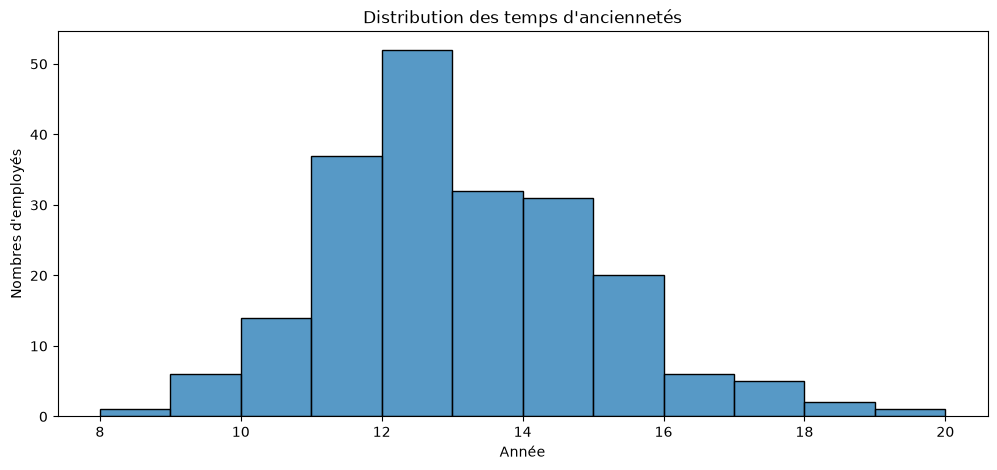

In [24]:
plt.figure(figsize=(12, 5))
sns.histplot(data_active, x='YearsWorkedTogether')

plt.title('Distribution des temps d\'anciennetés')
plt.xlabel('Année')
plt.ylabel('Nombres d\'employés')
plt.show()

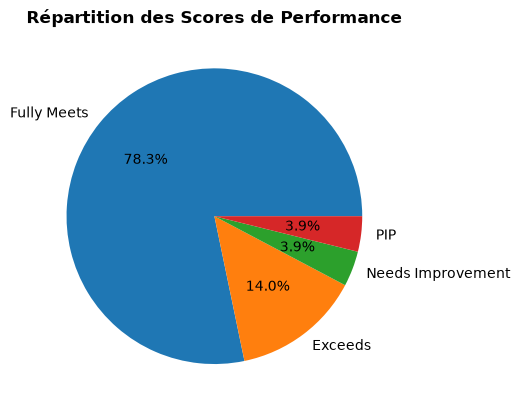

In [25]:
# On trace le graphique directement à partir de vos données dynamiques
data_active["PerformanceScore"].value_counts().plot(
    kind="pie",
    autopct="%.1f%%",  # Calcule et affiche les pourcentages automatiquement
)

plt.title("Répartition des Scores de Performance", weight="bold")
plt.show()

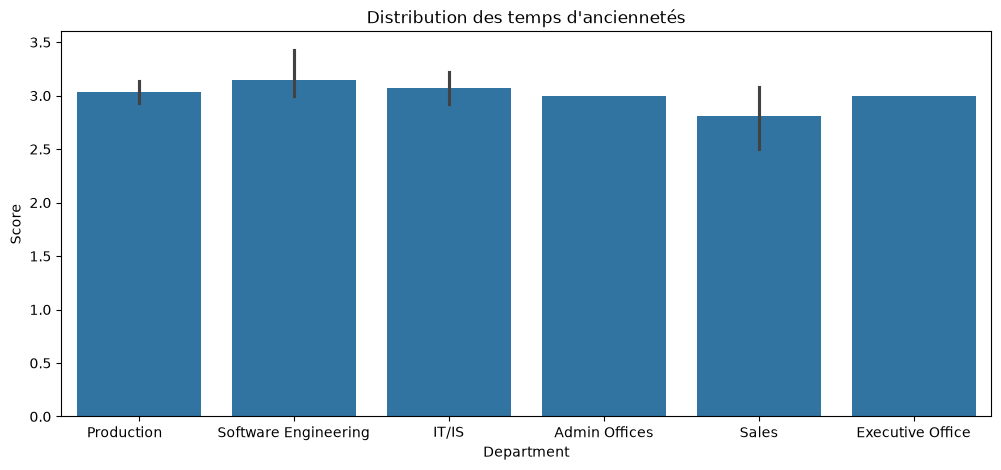

In [26]:
plt.figure(figsize=(12, 5))
sns.barplot(data_active, x='Department', y='PerfScoreID')

plt.title('Distribution des temps d\'anciennetés')
plt.xlabel('Department')
plt.ylabel('Score')
plt.show()

### Score et temps d'anciennetés (Scatterplot)

In [27]:
data_active['PerformanceScore'].value_counts()

PerformanceScore
Fully Meets          162
Exceeds               29
Needs Improvement      8
PIP                    8
Name: count, dtype: int64

In [28]:
data_active['PerfScoreID'].value_counts()

PerfScoreID
3    161
4     29
1      9
2      8
Name: count, dtype: int64

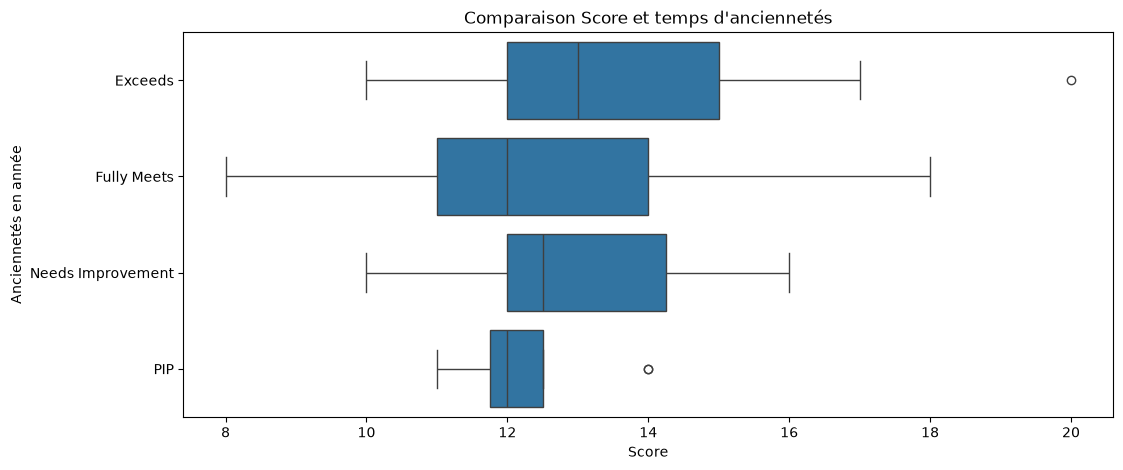

In [29]:
# Générer le graphique avec la taille dynamique
plt.figure(figsize=(12, 5))

sns.boxplot(
    data_active, 
    y='PerformanceScore', 
    x='YearsWorkedTogether'
)

plt.title("Comparaison Score et temps d'anciennetés")
plt.xlabel("Score")
plt.ylabel("Anciennetés en année")
plt.show()

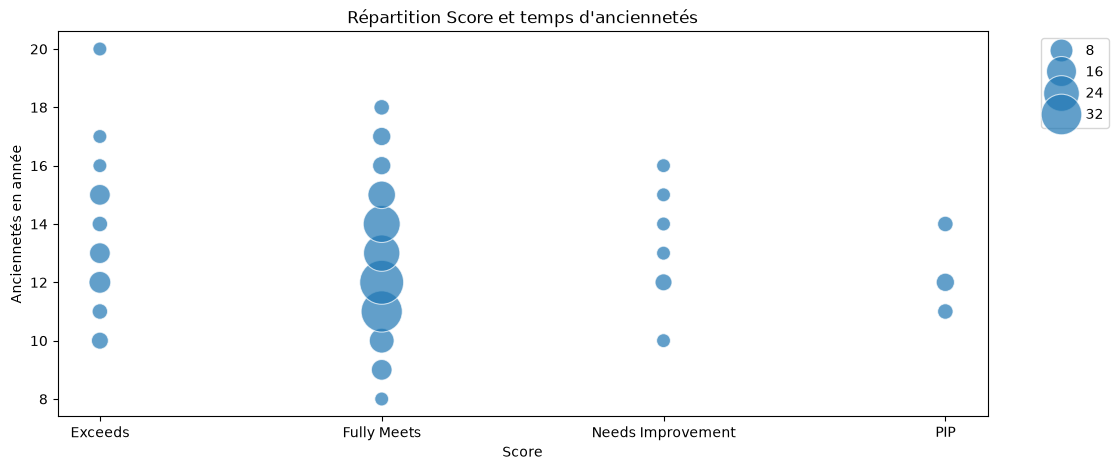

In [30]:
# 1. Grouper les données pour compter le nombre d'employés par combinaison (Score / Ancienneté)
data_counts = data_active.groupby(['PerformanceScore', 'YearsWorkedTogether']).size().reset_index(name='NombreEmployes')

# 2. Générer le graphique avec la taille dynamique
plt.figure(figsize=(12, 5))

sns.scatterplot(
    data=data_counts, 
    x='PerformanceScore', 
    y='YearsWorkedTogether', 
    size='NombreEmployes',  # Attribue la taille de la bulle à la nouvelle colonne
    sizes=(100, 1000),       # Définit la taille minimale et maximale des bulles (à ajuster selon vos préférences)
    alpha=0.7               # Ajoute de la transparence pour mieux voir les superpositions
)

plt.title("Répartition Score et temps d'anciennetés")
plt.xlabel("Score")
plt.ylabel("Anciennetés en année")

# Place la légende à l'extérieur du graphique pour ne pas cacher les bulles
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

### Salaire par département

Boîte à moustaches (Boxplot) — Salaire par Département

Objectif : Visualiser la dispersion des salaires, comparer les médianes d'un service à 
l'autre et détecter les valeurs aberrantes (outliers).

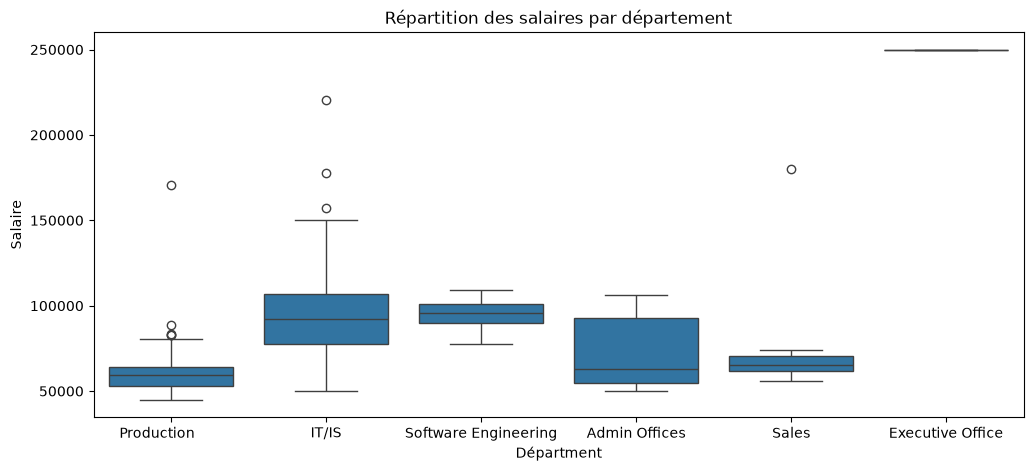

In [31]:
plt.figure(figsize=(12, 5))
sns.boxplot(data, x='Department', y='Salary')

plt.title('Répartition des salaires par département')
plt.xlabel('Départment')
plt.ylabel('Salaire')
plt.show()

### Recrutement

Graphique à barres horizontales — Performance et Rétention par Canal de Recrutement

Objectif : Comparer les canaux d'acquisition (LinkedIn, salons de la diversité, cooptation, cabinets) en croisant le volume d'embauches avec le taux de rétention post-embauche.

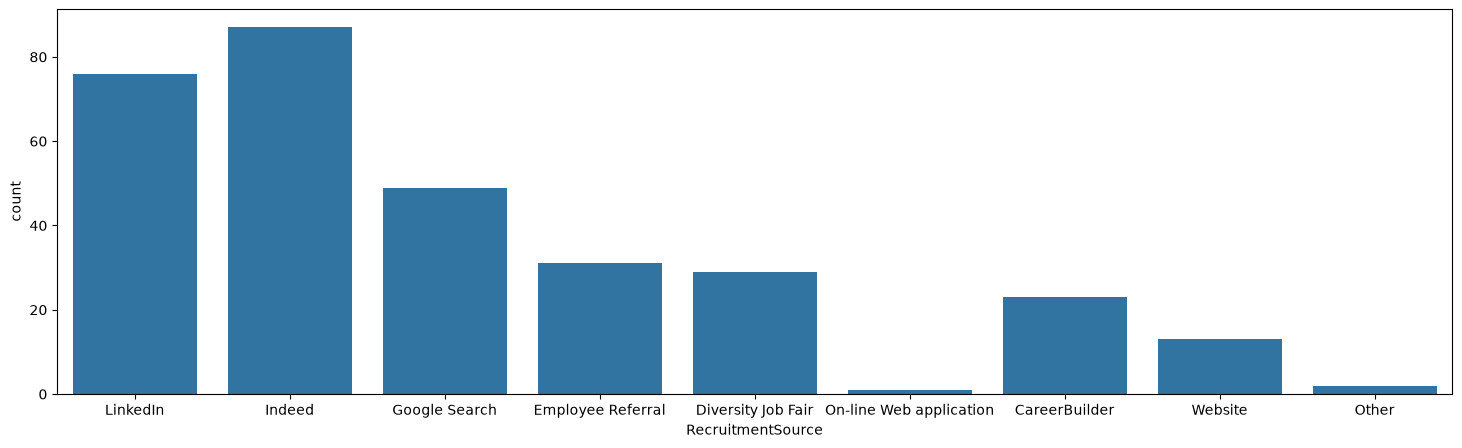

In [32]:
plt.figure(figsize=(18, 5))
sns.countplot(data, x='RecruitmentSource')

plt.show()